In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Create manufacturing dataset

data = {
    "Temperature": [
        180, 185, 190, 175, 200, 210, 195, 170, 188, 202,
        178, 192, 205, 182, 215, 176, 198, 187, 208, 193,
        181, 196, 203, 179, 189, 211, 174, 201, 186, 194
    ],
    "Pressure": [
        50, 52, 55, 48, 60, 65, 58, 45, 53, 61,
        49, 56, 63, 51, 68, 47, 59, 54, 66, 57,
        52, 60, 62, 48, 55, 67, 46, 64, 53, 58
    ],
    "Speed": [
        1200, 1250, 1300, 1100, 1500, 1600, 1400, 1000, 1280, 1520,
        1150, 1320, 1550, 1220, 1650, 1080, 1450, 1260, 1580, 1350,
        1180, 1420, 1510, 1120, 1290, 1620, 1050, 1560, 1240, 1380
    ],
    "Vibration": [
        2.1, 2.3, 2.5, 1.8, 4.2, 5.1, 3.8, 1.5, 2.4, 4.5,
        2.0, 2.7, 4.8, 2.2, 5.5, 1.7, 3.5, 2.6, 5.0, 3.0,
        2.1, 3.2, 4.0, 1.9, 2.5, 5.2, 1.6, 4.7, 2.3, 3.4
    ],
    "Quality": [
        "Good", "Good", "Good", "Good", "Defective", "Defective",
        "Good", "Good", "Good", "Defective", "Good", "Good",
        "Defective", "Good", "Defective", "Good", "Good", "Good",
        "Defective", "Good", "Good", "Good", "Defective", "Good",
        "Good", "Defective", "Good", "Defective", "Good", "Good"
    ]
}

df = pd.DataFrame(data)

# Save dataset as CSV
df.to_csv("manufacturing_quality_dataset.csv", index=False)

print("Dataset created successfully!")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset created successfully!
Dataset shape: (30, 5)

First 5 rows:
   Temperature  Pressure  Speed  Vibration    Quality
0          180        50   1200        2.1       Good
1          185        52   1250        2.3       Good
2          190        55   1300        2.5       Good
3          175        48   1100        1.8       Good
4          200        60   1500        4.2  Defective


In [5]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nQuality Distribution:")
print(df["Quality"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  30 non-null     int64  
 1   Pressure     30 non-null     int64  
 2   Speed        30 non-null     int64  
 3   Vibration    30 non-null     float64
 4   Quality      30 non-null     object 
dtypes: float64(1), int64(3), object(1)
memory usage: 1.3+ KB
None

Missing Values:
Temperature    0
Pressure       0
Speed          0
Vibration      0
Quality        0
dtype: int64

Quality Distribution:
Quality
Good         21
Defective     9
Name: count, dtype: int64


In [6]:
# Convert target labels into numerical values
df["Quality_Code"] = df["Quality"].map({
    "Good": 1,
    "Defective": 0
})

# Select input features and target
X = df[["Temperature", "Pressure", "Speed", "Vibration"]]
y = df["Quality_Code"]

print("Input Features:")
print(X.head())

print("\nTarget Values:")
print(y.head())

Input Features:
   Temperature  Pressure  Speed  Vibration
0          180        50   1200        2.1
1          185        52   1250        2.3
2          190        55   1300        2.5
3          175        48   1100        1.8
4          200        60   1500        4.2

Target Values:
0    1
1    1
2    1
3    1
4    0
Name: Quality_Code, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


In [8]:
# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [9]:
# Make predictions
y_pred = model.predict(X_test)

# Convert numerical predictions into labels
actual_labels = y_test.map({
    1: "Good",
    0: "Defective"
}).values

predicted_labels = pd.Series(y_pred).map({
    1: "Good",
    0: "Defective"
}).values

# Display prediction results
results = pd.DataFrame({
    "Actual Quality": actual_labels,
    "Predicted Quality": predicted_labels
})

print("Prediction Results:")
print(results)

Prediction Results:
  Actual Quality Predicted Quality
0      Defective         Defective
1           Good              Good
2           Good              Good
3           Good              Good
4      Defective         Defective
5           Good              Good


In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy: {:.2f}%".format(accuracy * 100))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Defective", "Good"]
))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

   Defective       1.00      1.00      1.00         2
        Good       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



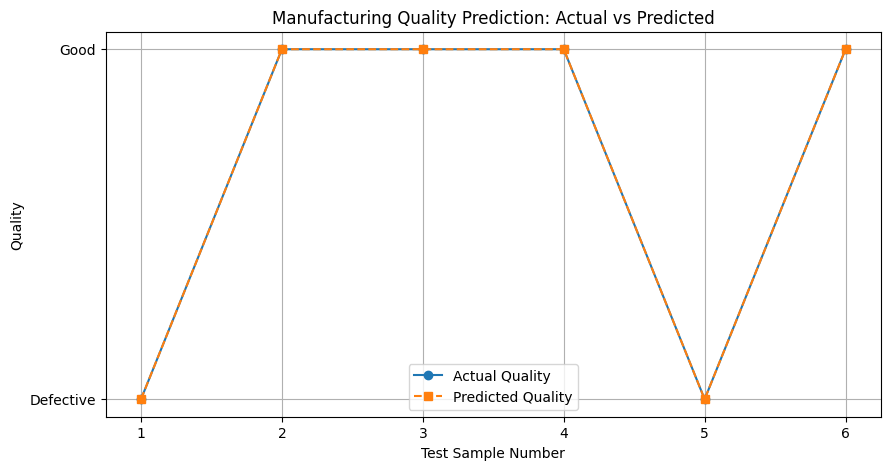

In [11]:
# Convert labels to numerical values for plotting
actual_numeric = y_test.values
predicted_numeric = y_pred

# Create graph
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(actual_numeric) + 1),
    actual_numeric,
    marker="o",
    label="Actual Quality"
)

plt.plot(
    range(1, len(predicted_numeric) + 1),
    predicted_numeric,
    marker="s",
    linestyle="--",
    label="Predicted Quality"
)

plt.yticks([0, 1], ["Defective", "Good"])
plt.xlabel("Test Sample Number")
plt.ylabel("Quality")
plt.title("Manufacturing Quality Prediction: Actual vs Predicted")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
# New manufacturing sample
new_product = pd.DataFrame({
    "Temperature": [185],
    "Pressure": [52],
    "Speed": [1250],
    "Vibration": [2.3]
})

# Predict quality
new_prediction = model.predict(new_product)

if new_prediction[0] == 1:
    print("Predicted Quality: Good")
else:
    print("Predicted Quality: Defective")

Predicted Quality: Good
